In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/cybersecurity.csv')
plt.style.use('ggplot')
df.head(5)

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   timestamp            10000 non-null  str  
 1   src_ip               10000 non-null  str  
 2   dst_ip               10000 non-null  str  
 3   src_port             10000 non-null  int64
 4   dst_port             10000 non-null  int64
 5   protocol             10000 non-null  str  
 6   bytes_sent           10000 non-null  int64
 7   bytes_received       10000 non-null  int64
 8   user_agent           10000 non-null  str  
 9   url                  6768 non-null   str  
 10  is_internal_traffic  10000 non-null  bool 
 11  label                10000 non-null  int64
 12  attack_type          10000 non-null  str  
dtypes: bool(1), int64(5), str(7)
memory usage: 2.6 MB


In [3]:
df.isnull().sum()

timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64

In [4]:
df.describe()

,src_port,dst_port,bytes_sent,bytes_received,label
count,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000
mean,27052.223700,2027.280500,1.412572e+05,2.620883e+05,0.040000
std,20978.783832,6769.141395,2.128140e+06,3.767695e+06,0.195969
min,21.000000,5.000000,1.700000e+01,3.000000e+00,0.000000
25%,6092.250000,25.000000,7.148250e+03,1.096075e+04,0.000000
50%,25431.500000,443.000000,2.181550e+04,3.747300e+04,0.000000
75%,45215.750000,1433.000000,6.509525e+04,1.213795e+05,0.000000
max,65524.000000,65491.000000,1.391704e+08,2.914830e+08,1.000000


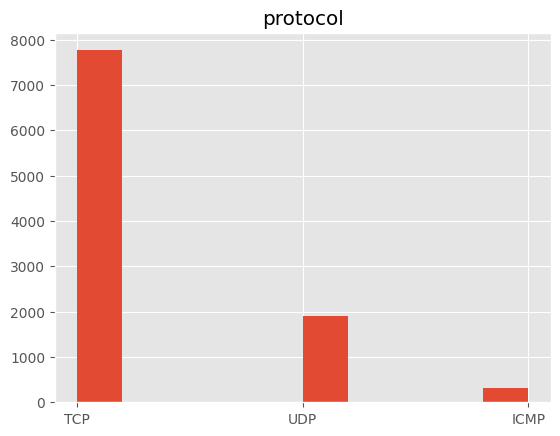

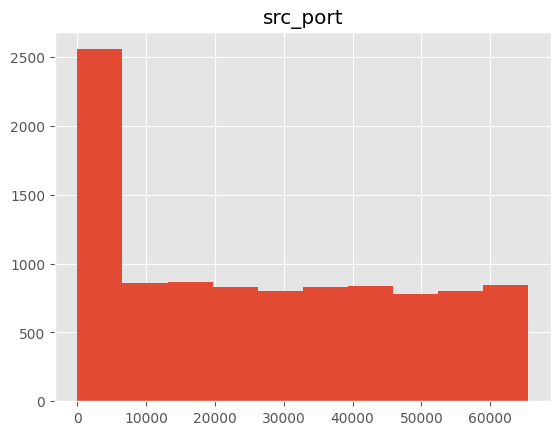

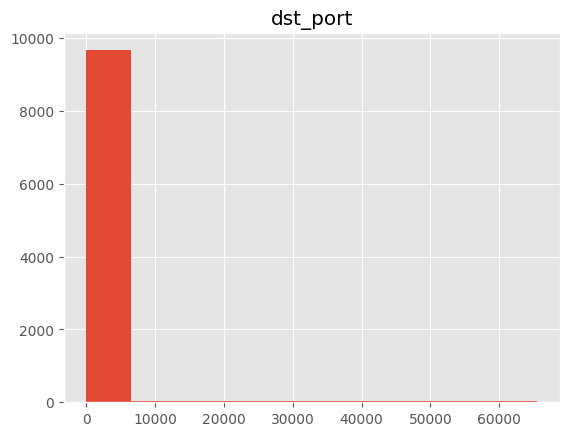

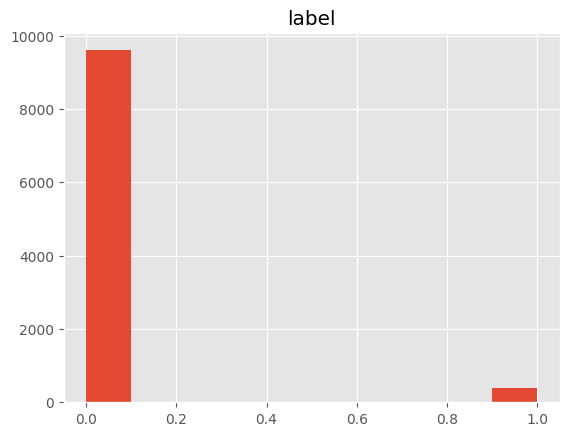

In [5]:
import matplotlib.pyplot as plt

columns = ['protocol', 'src_port', 'dst_port', 'label']

for col in columns:
    df[col].hist()
    plt.title(col)
    plt.show()

In [6]:
df['url'] = df['url'].fillna("")

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   timestamp            10000 non-null  str  
 1   src_ip               10000 non-null  str  
 2   dst_ip               10000 non-null  str  
 3   src_port             10000 non-null  int64
 4   dst_port             10000 non-null  int64
 5   protocol             10000 non-null  str  
 6   bytes_sent           10000 non-null  int64
 7   bytes_received       10000 non-null  int64
 8   user_agent           10000 non-null  str  
 9   url                  10000 non-null  str  
 10  is_internal_traffic  10000 non-null  bool 
 11  label                10000 non-null  int64
 12  attack_type          10000 non-null  str  
dtypes: bool(1), int64(5), str(7)
memory usage: 2.6 MB


In [8]:
df['timestamp'] = pd.to_datetime(df['timestamp'])


In [9]:
df['src_well_known_port'] = (df["src_port"] < 1024).astype(int)
df['dst_well_known_port'] = (df["dst_port"] < 1024).astype(int)

df['src_ephemeral_port'] = (df['src_port'] > 49152).astype(int)
df['dst_ephemeral_port'] = (df['dst_port'] > 49152).astype(int)

common_ports = [20, 21, 22, 23, 25, 53, 80, 110, 143, 443, 445, 993, 995, 1433, 3306, 3389, 5432, 8080, 8443]

df['src_is_common'] = (df['src_port']).isin(common_ports).astype(int)
df['dst_is_common'] = (df['dst_port']).isin(common_ports).astype(int)

df['port_diff'] = abs(df['dst_port'] - df['src_port'])


In [10]:
df['url_length'] = df['url'].apply(len)
df['url_has_login'] = df['url'].str.contains('login|logon|auth|signin', case = False).astype(int)
df['url_has_admin'] = df['url'].str.contains('admin|config|phpmyadmin|setup', case = False).astype(int)
df['url_has_id'] = df['url'].str.contains(r'\?id=', case = False).astype(int)

df['ua_isChrome'] = df['user_agent'].str.contains('Chrome',case = False).astype(int)
df['ua_isFirefox'] = df['user_agent'].str.contains('Firefox',case = False).astype(int)
df['ua_isWindow'] = df['user_agent'].str.contains('Window',case = False).astype(int)
df['ua_length'] = df['user_agent'].apply(len)
tool_patterns = 'sqlmap|zgrab|python-requests|python-urllib|curl'

df['ua_is_tool'] = df['user_agent'].str.contains(tool_patterns, case=False).astype(int)

In [11]:
df = pd.get_dummies(df, columns = ['protocol'])

In [12]:
df['is_internal_traffic'] = df['is_internal_traffic'].astype(int)

In [13]:
df['day'] = df['timestamp'].dt.day_of_week
df['hour'] = df['timestamp'].dt.hour

df['hour_sin'] = np.sin( 2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos( 2 * np.pi * df['hour'] / 24)

df['day_sin'] = np.sin(2 * np.pi * df['day'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 7)

In [14]:
src_ip_parts = df["src_ip"].str.split(".", expand=True).astype(int)
df["src_ip_first_octet"] = src_ip_parts[0]
df["src_ip_second_octet"] = src_ip_parts[1]
dst_ip_parts = df["dst_ip"].str.split(".", expand=True).astype(int)
df["dst_ip_first_octet"] = dst_ip_parts[0]
df["dst_ip_second_octet"] = dst_ip_parts[1]
df["src_ip_is_private"] = (
    (src_ip_parts[0] == 10) |
    ((src_ip_parts[0] == 172) & (src_ip_parts[1] >= 16) & (src_ip_parts[1] <= 31)) |
    ((src_ip_parts[0] == 192) & (src_ip_parts[1] == 168))
).astype(int)
df["dst_ip_is_private"] = (
    (dst_ip_parts[0] == 10) |
    ((dst_ip_parts[0] == 172) & (dst_ip_parts[1] >= 16) & (dst_ip_parts[1] <= 31)) |
    ((dst_ip_parts[0] == 192) & (dst_ip_parts[1] == 168))
).astype(int)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            10000 non-null  datetime64[us]
 1   src_ip               10000 non-null  str           
 2   dst_ip               10000 non-null  str           
 3   src_port             10000 non-null  int64         
 4   dst_port             10000 non-null  int64         
 5   bytes_sent           10000 non-null  int64         
 6   bytes_received       10000 non-null  int64         
 7   user_agent           10000 non-null  str           
 8   url                  10000 non-null  str           
 9   is_internal_traffic  10000 non-null  int64         
 10  label                10000 non-null  int64         
 11  attack_type          10000 non-null  str           
 12  src_well_known_port  10000 non-null  int64         
 13  dst_well_known_port  10000 non-null  int64 

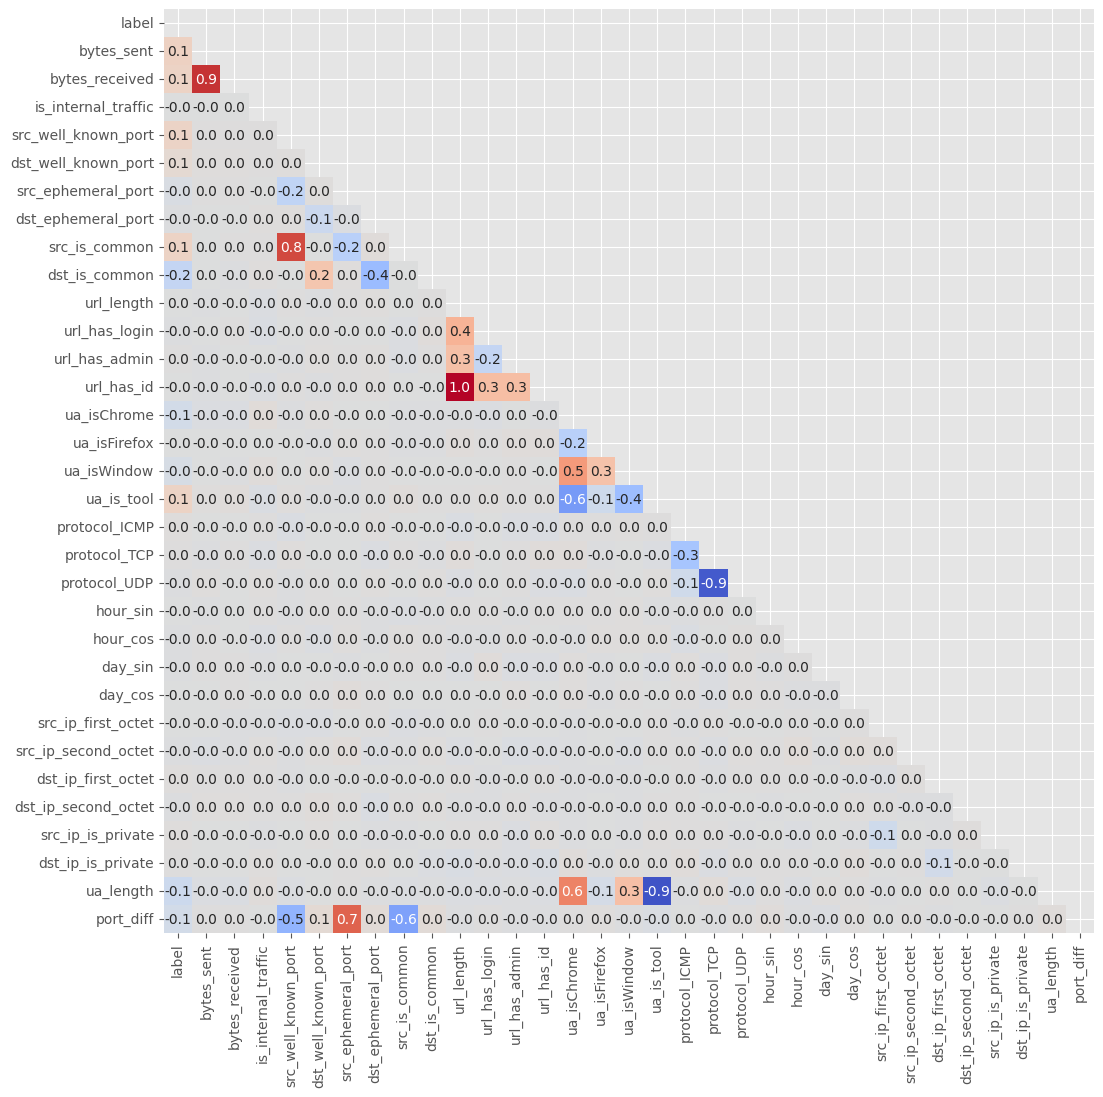

In [16]:
import seaborn as sns

feature = [
    'bytes_sent', 'bytes_received', 'is_internal_traffic',
    'src_well_known_port',
    'dst_well_known_port', 
    'src_ephemeral_port',
    'dst_ephemeral_port',        
 'src_is_common',             
 'dst_is_common',             
 'url_length',             
 'url_has_login',             
 'url_has_admin',             
 'url_has_id',             
 'ua_isChrome',             
 'ua_isFirefox',             
 'ua_isWindow',             
 'ua_is_tool',             
 'protocol_ICMP',             
 'protocol_TCP',             
 'protocol_UDP',               
 'hour_sin',             
 'hour_cos',             
 'day_sin',             
 'day_cos',             
 'src_ip_first_octet',     
 'src_ip_second_octet',     
 'dst_ip_first_octet',     
 'dst_ip_second_octet',     
 'src_ip_is_private',    
 'dst_ip_is_private',
 'ua_length',
 'port_diff',
 ]

target = [
    'label'
]
matrix = df[target + feature].corr()

mask = np.triu(np.ones_like(matrix, dtype = bool))


plt.figure(figsize = (12, 12))
sns.heatmap(matrix, mask= mask, cmap = 'coolwarm', cbar = False,
            annot = True, fmt = '.1f', center = 0)

plt.show()



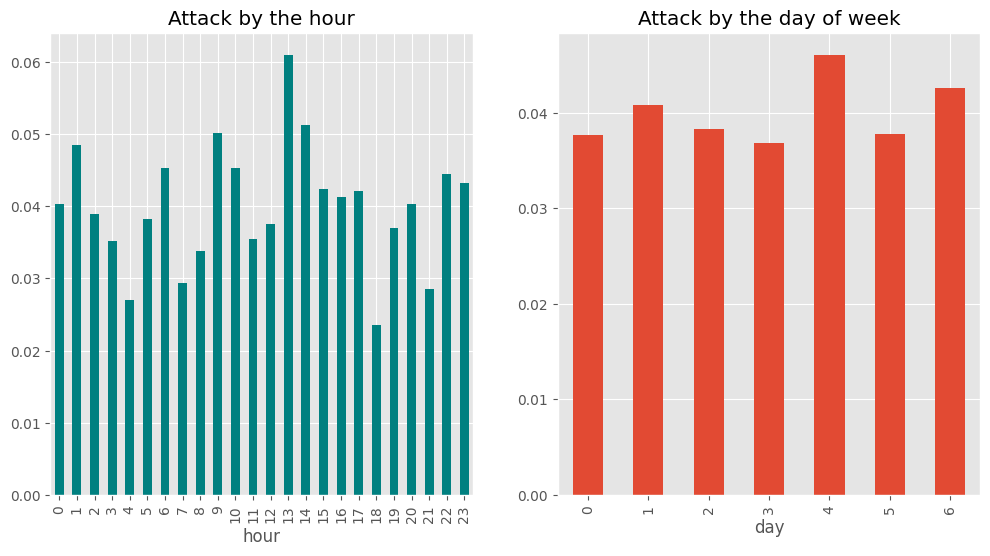

In [17]:
attack_by_hour = df.groupby('hour')['label'].mean()
attack_by_day = df.groupby('day')['label'].mean()


plt.figure(figsize= (12 ,6))
plt.subplot(1, 2, 1)
attack_by_hour.plot(kind = 'bar', color = 'teal')
plt.title("Attack by the hour")

plt.subplot(1, 2, 2)
attack_by_day.plot(kind = 'bar')
plt.title("Attack by the day of week")

plt.show()

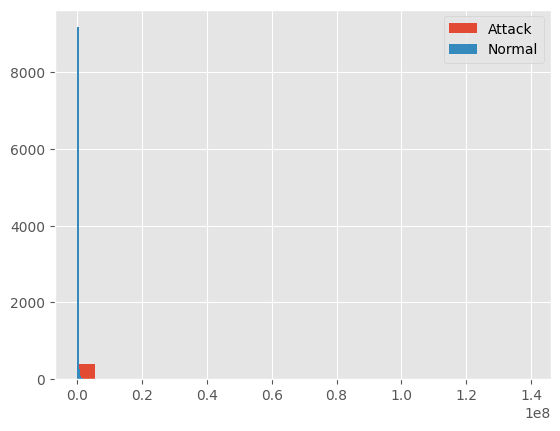

In [18]:
df_attack = df[df['label'] == 1]
df_normal = df[df['label'] == 0]

plt.hist(df_attack['bytes_sent'], bins = 25, label = 'Attack')
plt.hist(df_normal['bytes_sent'], bins = 25, label = 'Normal')

plt.legend()

plt.show()

In [19]:
# feature_to_use = [
#     'bytes_sent',
#     'bytes_received',
#     'src_well_known_port',
#     'dst_well_known_port',
#     'src_is_common',
#     'dst_is_common',
#     'ua_isChrome',
#     'ua_is_tool'
# ]


feature_to_use = feature


In [20]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = df[feature_to_use].copy()
y = df[target].copy()

X_train, X_temp, y_train,  y_temp = train_test_split(X, y, train_size= 0.7, random_state= 8, stratify= y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size= 0.5, random_state= 8, stratify= y_temp)

print(X_train.shape, X_val.shape, X_test.shape)


(7000, 32) (1500, 32) (1500, 32)


In [21]:
sm = SMOTE(random_state= 8)

print('Original training label:' , y_train.shape)

X_train_updated, y_train_updated = sm.fit_resample(X_train, y_train)

print('SMOTED training label:' , y_train_updated.shape)

Original training label: (7000, 1)
SMOTED training label: (13440, 1)


In [22]:
from xgboost import XGBClassifier


xgb = XGBClassifier(
    n_estimators = 1000,
    random_state = 8,
    learning_rate = 0.05,
    early_stopping_rounds = 50,
    eval_metric = 'aucpr'
)

xgb.fit(
    X_train_updated, y_train_updated,
        # X_train, y_train,
        eval_set = [(X_val, y_val)],
        verbose = 100)



[0]	validation_0-aucpr:0.63454
[57]	validation_0-aucpr:0.55587


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'aucpr'


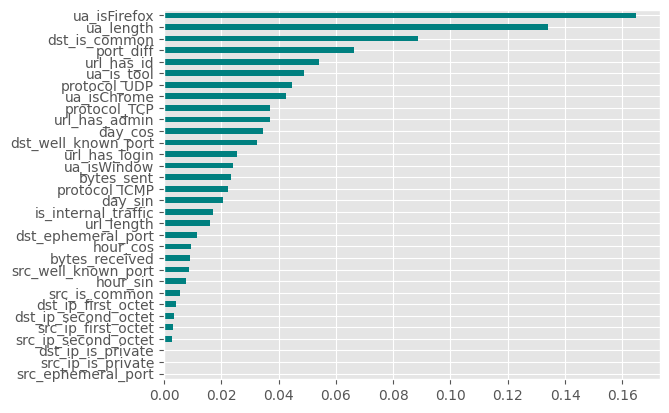

In [23]:

feat_imp = pd.Series(xgb.feature_importances_, index = feature_to_use).sort_values()

feat_imp.plot(kind= 'barh', color = 'teal')
plt.show()

              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1440
           1       0.29      0.72      0.41        60

    accuracy                           0.92      1500
   macro avg       0.64      0.82      0.68      1500
weighted avg       0.96      0.92      0.93      1500



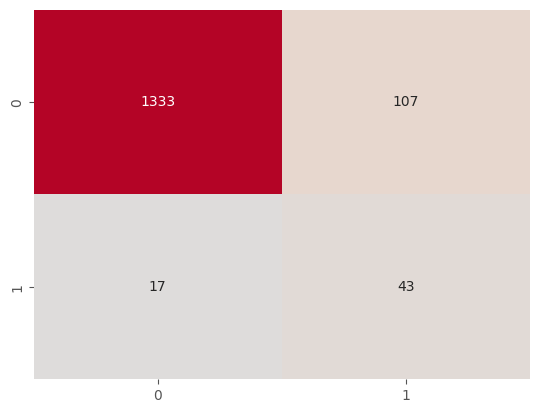

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_val = xgb.predict(X_val)

print(classification_report(y_true= y_val, y_pred= y_pred_val))

cm = confusion_matrix(y_true= y_val, y_pred= y_pred_val)
sns.heatmap(cm, cmap = 'coolwarm', annot = True, fmt = 'd',
            center = 0, cbar = False)

plt.show()

Best Threshold:  0.6394044
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1440
           1       0.78      0.48      0.60        60

    accuracy                           0.97      1500
   macro avg       0.88      0.74      0.79      1500
weighted avg       0.97      0.97      0.97      1500



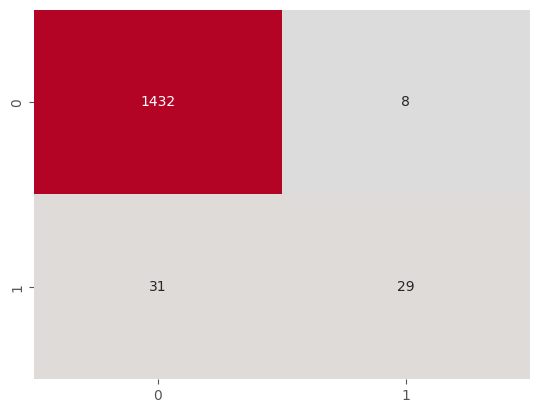

In [25]:
from sklearn.metrics import precision_recall_curve

y_prob = xgb.predict_proba(X_val)[:,1]
precision, recall, thresholds = precision_recall_curve(y_val, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print("Best Threshold: ", best_threshold)
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print(classification_report(y_val, y_pred_tuned))

cm = confusion_matrix(y_true= y_val, y_pred= y_pred_tuned)
sns.heatmap(cm, cmap = 'coolwarm', annot = True, fmt = 'd',
            center = 0, cbar = False)

plt.show()

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1440
           1       0.89      0.42      0.57        60

    accuracy                           0.97      1500
   macro avg       0.93      0.71      0.78      1500
weighted avg       0.97      0.97      0.97      1500



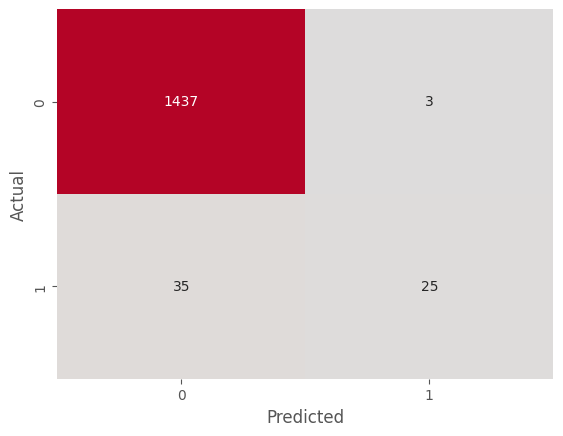

In [26]:
y_prob_test = xgb.predict_proba(X_test)[:,1]

y_final = (y_prob_test >= best_threshold).astype(int)

print(classification_report(y_test, y_final))

cm = confusion_matrix(y_true= y_test, y_pred= y_final)
sns.heatmap(cm, cmap = 'coolwarm', annot = True, fmt = 'd',
            center = 0, cbar = False)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1440
           1       0.35      0.68      0.46        60

    accuracy                           0.94      1500
   macro avg       0.67      0.81      0.71      1500
weighted avg       0.96      0.94      0.95      1500



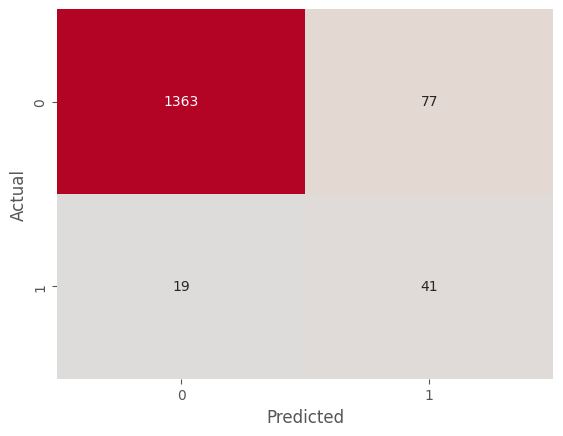

In [27]:
y_xgb = xgb.predict(X_test)


print(classification_report(y_test, y_xgb))

cm = confusion_matrix(y_true= y_test, y_pred= y_xgb)
sns.heatmap(cm, cmap = 'coolwarm', annot = True, fmt = 'd',
            center = 0, cbar = False)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
from sklearn.ensemble import GradientBoostingClassifier


grad = GradientBoostingClassifier(
    n_estimators= 200,

)

grad.fit(X_train, y_train.values.ravel())



,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Best Threshold:  0.560026013003732
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1440
           1       0.74      0.53      0.62        60

    accuracy                           0.97      1500
   macro avg       0.86      0.76      0.80      1500
weighted avg       0.97      0.97      0.97      1500



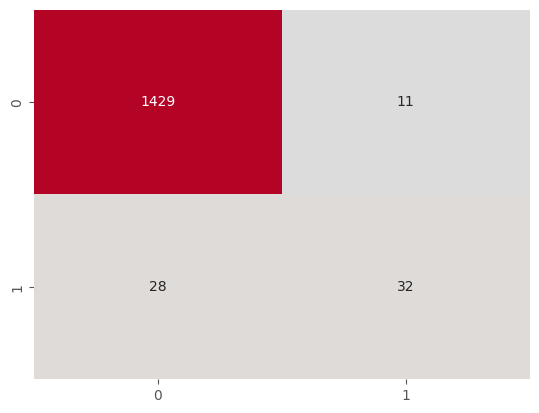

In [29]:
y_prob = grad.predict_proba(X_val)[:,1]
precision, recall, thresholds = precision_recall_curve(y_val, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print("Best Threshold: ", best_threshold)
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print(classification_report(y_val, y_pred_tuned))

cm = confusion_matrix(y_true= y_val, y_pred= y_pred_tuned)
sns.heatmap(cm, cmap = 'coolwarm', annot = True, fmt = 'd',
            center = 0, cbar = False)

plt.show()

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1440
           1       0.73      0.55      0.63        60

    accuracy                           0.97      1500
   macro avg       0.86      0.77      0.81      1500
weighted avg       0.97      0.97      0.97      1500



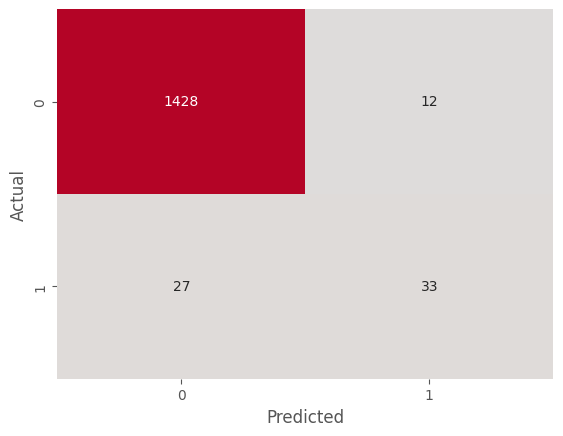

In [30]:
y_prob_test = grad.predict_proba(X_test)[:,1]

y_final = (y_prob_test >= best_threshold).astype(int)

print(classification_report(y_test, y_final))

cm = confusion_matrix(y_true= y_test, y_pred= y_final)
sns.heatmap(cm, cmap = 'coolwarm', annot = True, fmt = 'd',
            center = 0, cbar = False)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1440
           1       0.74      0.62      0.67        60

    accuracy                           0.98      1500
   macro avg       0.86      0.80      0.83      1500
weighted avg       0.97      0.98      0.97      1500



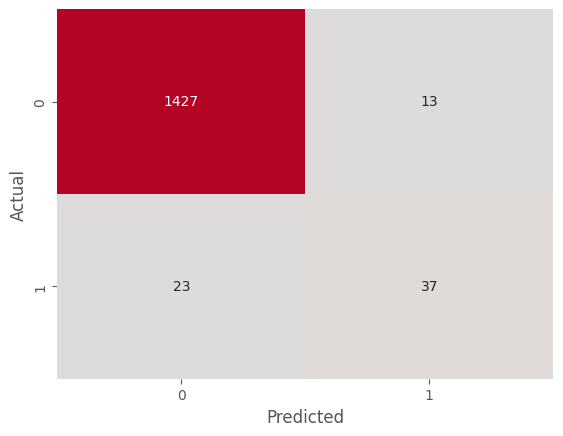

In [31]:
y_grad = grad.predict(X_test)

print(classification_report(y_test, y_grad))

cm = confusion_matrix(y_true= y_test, y_pred= y_grad)
sns.heatmap(cm, cmap = 'coolwarm', annot = True, fmt = 'd',
            center = 0, cbar = False)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()